In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns

from rebinding.efflux_model_collection import washout_vary_bound
from rebinding.fig_utils import save_fig, defaultStyle
defaultStyle(fs=14)

# PK

(0, 96) [0.00000000e+00 1.00001389e-02 2.00002778e-02 ... 9.59713329e+01
 9.59813331e+01 9.59913332e+01]
(96, 192) [ 96.00133335  96.01133349  96.02133363 ... 191.97266629 191.98266643
 191.99266656]
(192, 720) [192.0026667  192.01266684 192.02266698 ... 719.97999972 719.98999986
 720.        ]


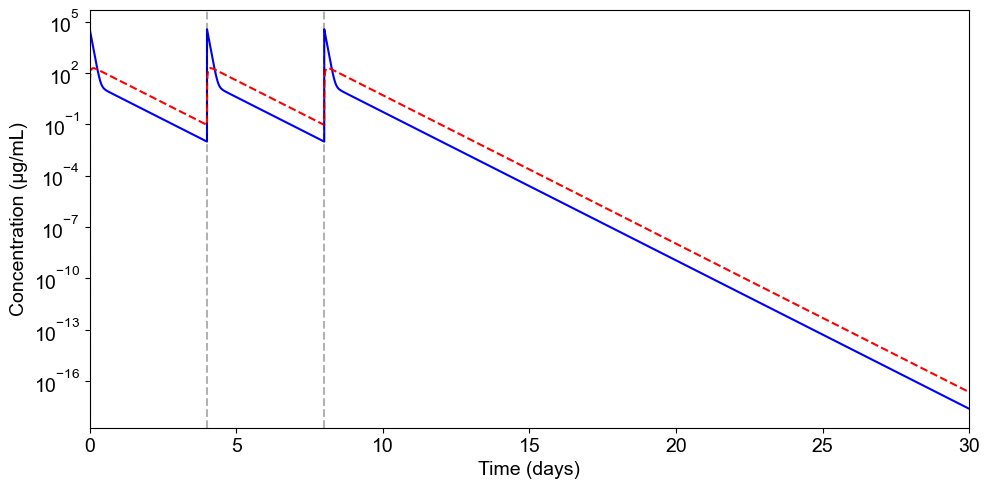

In [3]:
# Parameters for the two-compartment model
V1 = 0.81  # Central compartment volume (L/kg)
k10 = 0.868  # Elimination rate constant from central compartment (h^-1)
k12 = 0.0060  # Rate constant from central to peripheral compartment (h^-1)
k21 = 0.0838  # Rate constant from peripheral to central compartment (h^-1)
CL = 0.7  # Plasma clearance (L/h/kg)
dosing_interval = 4 * 24  # Every 4 days in hours
num_doses = 3  # Number of doses
peak_conc = 10**4.55  # μg/mL (specified maximum plasma concentration)

# Convert peak concentration from μg/mL to mg/L for internal calculations
peak_conc_mg_L = peak_conc / 1000


# Define the differential equations for the two-compartment model
def pk_model(t, y, k10, k12, k21):
    C1, C2 = y
    dC1dt = -k10 * C1 - k12 * C1 + k21 * C2
    dC2dt = k12 * C1 - k21 * C2
    return [dC1dt, dC2dt]


# Time points to solve the equations (every hour for 12 days)
t_span = (0, 30 * 24)  # 12 days simulation
t_eval = np.linspace(0, 30 * 24, 30 * 24 * 100)  # hourly evaluation points

# Initial conditions - Starting with the peak concentration
y0 = [
    peak_conc_mg_L,
    0,
]  # Initial concentrations in central and peripheral compartments

# Array to store concentrations over time
C1_total = np.zeros_like(t_eval)
C2_total = np.zeros_like(t_eval)


# Function to add a dose
def add_dose(C1, peak_conc_mg_L):
    return peak_conc_mg_L  # Set to peak concentration directly


# Administer doses
for dose_num in range(num_doses):
    dose_time = dose_num * dosing_interval

    # Find the closest time point to the dose administration
    dose_index = np.abs(t_eval - dose_time).argmin()

    # Initial concentration after the dose is administered
    if dose_num == 0:
        initial_conc = [peak_conc_mg_L, 0]  # First dose
    else:
        initial_conc = [peak_conc_mg_L, 0]  #  C2_total[dose_index]]  # Subsequent doses

    # Time span for this dose
    if dose_num < num_doses - 1:
        t_dose_span = (dose_time, (dose_num + 1) * dosing_interval)
        t_dose_eval = t_eval[
            (t_eval >= dose_time) & (t_eval < (dose_num + 1) * dosing_interval)
        ]
    else:
        t_dose_span = (dose_time, 30 * 24)  # Last dose to end of simulation
        t_dose_eval = t_eval[t_eval >= dose_time]

    # Solve the ODEs for this dosing interval using solve_ivp
    print(t_dose_span, t_dose_eval)
    sol = solve_ivp(
        pk_model,
        t_dose_span,
        initial_conc,
        args=(k10, k12, k21),
        # method='RK45',
        t_eval=t_dose_eval,
        dense_output=True,
        max_step=2,
    )

    # Update the total concentrations
    idx_start = np.where(t_eval >= dose_time)[0][0]
    idx_end = idx_start + len(sol.y[0])
    C1_total[idx_start:idx_end] = sol.y[0]
    C2_total[idx_start:idx_end] = sol.y[1]

# Convert concentration back to μg/mL for plotting
C1_ug_ml = C1_total * 1000
C2_ug_ml = C2_total * 1000

# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the results
ax.plot(t_eval / 24, C1_ug_ml, "b-")
ax.plot(t_eval / 24, C2_ug_ml, "r--")

# Add vertical lines for dosing times (simplified, no text)
for i in range(num_doses):
    ax.axvline(x=i * dosing_interval / 24, color="k", linestyle="--", alpha=0.3)

# Set axis labels
ax.set_xlabel("Time (days)")
ax.set_ylabel("Concentration (μg/mL)")
ax.set_xlim(0, 30)
ax.set_yscale("log")

# Display the plot
plt.tight_layout()

# PD

In [4]:
def pk_results(s, d0=13):
    if s < d0:
        return 0
    s_index = np.abs(t_eval - (s - d0) * 24).argmin()
    return C1_ug_ml[s_index]


def pd_model(t, x, k1, k2, l0, l1, x1, d0, perturb=True):
    x1, x2, x3, x4 = x
    w = np.sum(x)
    p = 20
    c = pk_results(t, d0) if perturb else 0
    dx1dt = l0 * x1 / ((1 + (l0 * w / l1) ** p) ** (1 / p)) - k2 * c * x1
    dx2dt = k2 * c * x1 - k1 * x2
    dx3dt = k1 * (x2 - x3)
    dx4dt = k1 * (x3 - x4)
    return [dx1dt, dx2dt, dx3dt, dx4dt]


def pd_model_stepfn(t, x, l0, l1, ad_times, duration):
    p = 20
    if t <= ad_times[0]:
        E_drug = 0
    else:
        last_ad = ad_times[np.where(ad_times <= t)[0][-1]]
        t_post_infusion = t - last_ad
        E_drug = 1 if t_post_infusion <= duration else 0
    dxdt = l0 * x / ((1 + (l0 * x / l1) ** p) ** (1 / p)) * (1 - E_drug)
    return [dxdt]

# Raw data
def load_tumor_data(path, control, xmax=35, ymax=18):
    data = pd.read_csv(path, header=None).values
    tumor_data = np.zeros((data.shape[0], 3))
    tumor_data[:, 0] = data[:, 0] * xmax
    tumor_data[:, 1] = data[:, 1] * ymax
    tumor_data[:, 2] = control
    return tumor_data


data_1 = np.concatenate(
    [
        load_tumor_data("../data/Simeoni_2004/exp1_control.csv", control=0),
        load_tumor_data("../data/Simeoni_2004/exp1_treat.csv", control=1),
    ]
)
df_1 = pd.DataFrame(data=data_1, columns=["t", "w", "group"])
data_2 = np.concatenate(
    [
        load_tumor_data("../data/Simeoni_2004/exp2_control.csv", control=0),
        load_tumor_data("../data/Simeoni_2004/exp2_treat.csv", control=1),
    ]
)
df_2 = pd.DataFrame(data=data_2, columns=["t", "w", "group"])

## Group 1

In [5]:
k1 = 0.968
k2 = 6.29e-4
l0 = 0.273
l1 = 0.814
x1 = 0.055

tmax = 35
pd_results = solve_ivp(
    pd_model,
    t_span=(0, tmax),
    y0=[x1, 0, 0, 0],
    args=(k1, k2, l0, l1, x1, 13, True),
    max_step=0.1,
)
pd_results_unperturb = solve_ivp(
    pd_model,
    t_span=(0, tmax),
    y0=[x1, 0, 0, 0],
    args=(k1, k2, l0, l1, x1, 13, False,),
    max_step=0.1,
)
pd_results_stepfn = solve_ivp(
    pd_model_stepfn,
    t_span=(0, tmax),
    y0=[x1],
    args=(l0, l1, np.array([13, 17, 21]), 4),
    max_step=0.1,
)
pd_results_stepfn_unperterb = solve_ivp(
    pd_model_stepfn,
    t_span=(0, tmax),
    y0=[x1],
    args=(l0, l1, np.array([100]), 4),
    max_step=0.1,
)

Saving figure figEx8_tumor_1


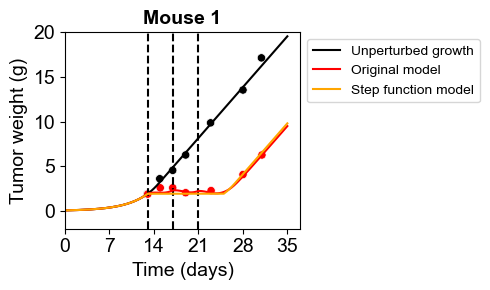

In [6]:
_, ax = plt.subplots(figsize=(5, 3))
sns.set_palette(["black", "red"])
sns.scatterplot(df_1, x="t", y="w", hue="group", ax=ax, legend=False)
for t in [13, 17, 21]:
    ax.axvline(t, ls="--", c="k")
# for t in [8, 12, 16]:
#     ax[1].axvline(t, ls="--", c="k")

ax.set_ylim(-2, 20)
ax.set_xlim(0, 37)
ax.plot(pd_results_unperturb.t, pd_results_unperturb.y.sum(axis=0), color="k", label="Unperturbed growth")
ax.plot(pd_results.t, pd_results.y.sum(axis=0), label="Original model", color="r")
# ax[0].plot(pd_results_stepfn_full.t, pd_results_stepfn_full.y.sum(axis=0))
ax.plot(pd_results_stepfn.t, pd_results_stepfn.y.sum(axis=0), label="Step function model", color="orange")
ax.set_xlabel("Time (days)")
ax.set_xticks(range(0, 40, 7))
ax.set_ylabel("Tumor weight (g)")
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title("Mouse 1", fontsize=14, fontweight="bold")
save_fig("figEx8_tumor_1", fmt="png", dpi=300)

In [7]:
k1 = 0.968
k2 = 6.29e-4
l0 = 0.311
l1 = 0.656
x1 = 0.033

tmax = 35
pd_results = solve_ivp(
    pd_model,
    t_span=(0, tmax),
    y0=[x1, 0, 0, 0],
    args=(k1, k2, l0, l1, x1, 8, True),
    max_step=0.1,
)
pd_results_unperturb = solve_ivp(
    pd_model,
    t_span=(0, tmax),
    y0=[x1, 0, 0, 0],
    args=(k1, k2, l0, l1, x1, 8, False),
    max_step=0.1,
)
pd_results_stepfn = solve_ivp(
    pd_model_stepfn,
    t_span=(0, tmax),
    y0=[x1],
    args=(l0, l1, np.array([8, 12, 16]), 3.7),
    max_step=0.1,
)

Saving figure figEx8_tumor_2


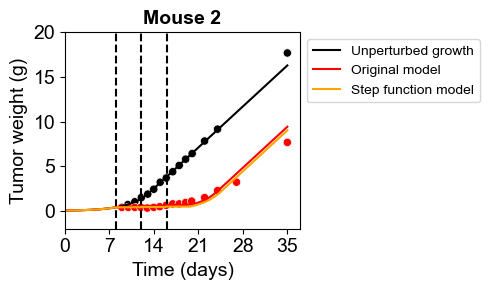

In [8]:
_, ax = plt.subplots(figsize=(5, 3))
sns.set_palette(["black", "red"])
sns.scatterplot(df_2, x="t", y="w", hue="group", ax=ax, legend=False)
for t in [8, 12, 16]:
    ax.axvline(t, ls="--", c="k")

ax.set_ylim(-2, 20)
ax.set_xlim(0, 37)
ax.plot(pd_results_unperturb.t, pd_results_unperturb.y.sum(axis=0), color="k", label="Unperturbed growth")
ax.plot(pd_results.t, pd_results.y.sum(axis=0), label="Original model", color="r")
# ax[0].plot(pd_results_stepfn_full.t, pd_results_stepfn_full.y.sum(axis=0))
ax.plot(pd_results_stepfn.t, pd_results_stepfn.y.sum(axis=0), label="Step function model", color="orange")
ax.set_xlabel("Time (days)")
ax.set_xticks(range(0, 40, 7))
ax.set_ylabel("Tumor weight (g)")
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title("Mouse 2", fontsize=14, fontweight="bold")
save_fig("figEx8_tumor_2", fmt="png", dpi=300)